C:\Users\Almazt\AppData\Local\Temp\ipykernel_25332\1004480227.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()



--- CRASH DETAILS ---
---------------------

Visualizations script finished checking!


Traceback (most recent call last):
  File "C:\Users\Almazt\AppData\Local\Temp\ipykernel_25332\1004480227.py", line 104, in <module>
    plot_top_themes(df)
    ~~~~~~~~~~~~~~~^^^^
  File "C:\Users\Almazt\AppData\Local\Temp\ipykernel_25332\1004480227.py", line 72, in plot_top_themes
    ax=axes[i],
       ~~~~^^^
IndexError: index 2 is out of bounds for axis 0 with size 2


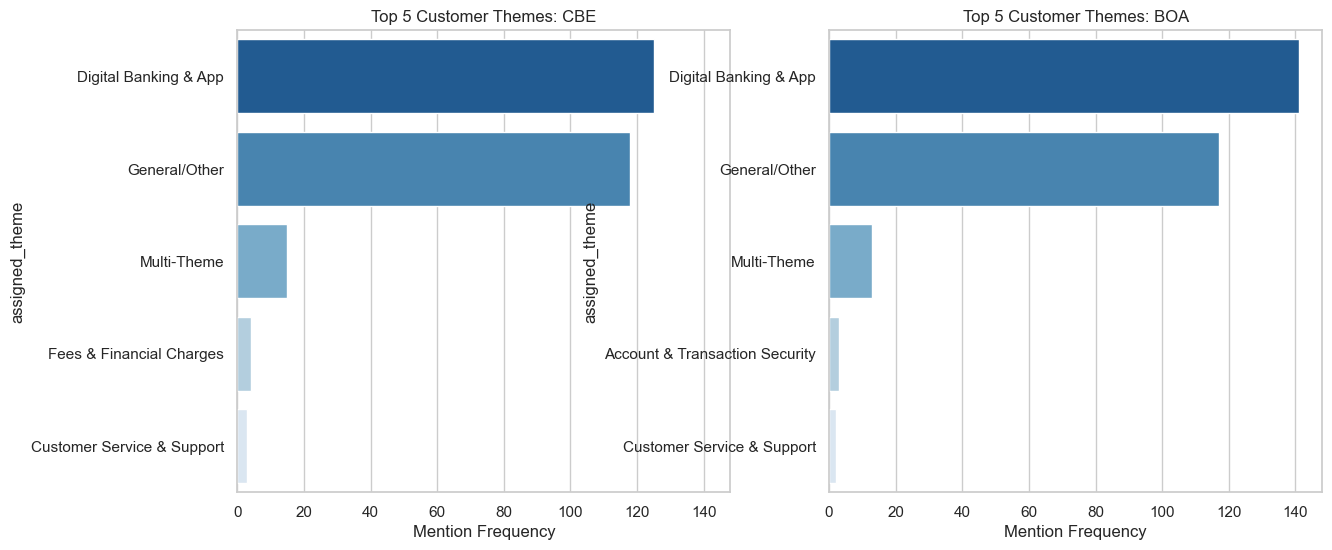

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set style for professional, scannable charts
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.titlesize"] = 16


def plot_sentiment_distribution(df):
    """Generates a stacked bar chart showing sentiment distribution by bank."""
    plt.figure(figsize=(10, 6))

    # Pivot data to get counts of sentiment per bank
    sentiment_counts = (
        df.groupby(["bank", "sentiment_score"])
        .size()
        .unstack(fill_value=0)
        .apply(lambda x: x / x.sum() * 100, axis=1)
    )

    # Plot
    colors = ["#e74c3c", "#95a5a6", "#2ecc71"]  # Negative, Neutral, Positive
    sentiment_counts.plot(kind="bar", stacked=True, color=colors, ax=plt.gca())

    plt.title("Customer Sentiment Distribution: CBE, BOA vs. Dashen", pad=20)
    plt.xlabel("Bank")
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=0)
    plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("sentiment_distribution.png", dpi=300)
    plt.close()


def plot_rating_distribution(df):
    """Generates a boxplot showing customer ratings distribution per bank."""
    plt.figure(figsize=(9, 6))

    sns.boxplot(
        x="bank",
        y="score",
        data=df,
        palette="Set2",
        hue="bank",
        legend=False,
    )

    plt.title("App Rating Distribution & Spread", pad=20)
    plt.xlabel("Bank")
    plt.ylabel("Rating (1-5 Stars)")
    plt.tight_layout()
    plt.savefig("rating_distribution.png", dpi=300)
    plt.close()


def plot_top_themes(df):
    """Generates a horizontal bar chart of dominant themes/keywords."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

    banks = df["bank"].unique()

    for i, bank in enumerate(banks):
        bank_df = df[df["bank"] == bank]
        # Assuming you have a 'theme' or 'keyword' column from Task 2/3
        top_themes = bank_df["assigned_theme"].value_counts().head(5)

        sns.barplot(
            x=top_themes.values,
            y=top_themes.index,
            ax=axes[i],
            palette="Blues_r",
            hue=top_themes.index,
            legend=False,
        )
        axes[i].set_title(f"Top 5 Customer Themes: {bank}")
        axes[i].set_xlabel("Mention Frequency")

    plt.suptitle("Dominant Themes Driving Customer Conversations", y=1.02)
    plt.tight_layout()
    plt.savefig("top_themes.png", dpi=300)
    plt.close()


""" # Example Usage (Uncomment and point to your final cleaned dataset)
if __name__ == "__main__":
    df = pd.read_csv("../data/processed/reviews_with_sentiment.csv")
    plot_sentiment_distribution(df)
    plot_rating_distribution(df)
    print(df['theme_column_name'].nunique())
    plot_top_themes(df)
    
    print("Visualizations successfully generated and saved!")
 """
 
if __name__ == "__main__":
    df = pd.read_csv("../data/processed/reviews_with_sentiment.csv")
    plot_sentiment_distribution(df)
    plot_rating_distribution(df)

    # Wrap it in a try/except to capture the exact traceback
    try:
        plot_top_themes(df)
    except Exception as e:
        import traceback

        print("\n--- CRASH DETAILS ---")
        traceback.print_exc()
        print("---------------------\n")

    print("Visualizations script finished checking!")